# Week 2 M1-N2
#### please submit the printed notebook (.pdf) and the notebook (.ipynb) itself on gradescope

[Enter Names] Your Name: __________   
 Partners: __________



In this lab, you'll implement the k-Nearest Neighbors (k-NN) algorithm from scratch and apply it to a real-world problem: predicting wine quality based on chemical properties. The wine quality dataset contains physicochemical measurements (like acidity, sugar content, alcohol percentage) of Portuguese "Vinho Verde" wines, along with quality ratings by expert sommeliers.

**Roadmap**
- Part 1: Load and Explore the Dataset
- Part 2: Preprocess dataset
- Part 3: Implement k-NN Algorithm
- Part 4: Evaluation and Interpretation
- Part 5: Discussion Questions
- Part 6: Weighted k-NN (Optional)

**Learning Objectives**
- Understand the k-NN algorithm and how it makes predictions based on proximity
- Implement distance calculations and neighbor selection
- Explore the effect of the parameter k on classification accuracy
- Learn about feature normalization and why it matters
- Visualize decision boundaries in 2D

**Dataset Information**
The wine quality dataset includes:
- **Features**: 11 physicochemical properties (fixed acidity, volatile acidity, citric acid, residual sugar, chlorides, free/total sulfur dioxide, density, pH, sulphates, alcohol)
- **Target**: Quality score (0-10, rated by wine experts)
- **Samples**: ~6500 wines (white and red varieties)

We'll simplify the problem by classifying wines as "good" (quality ≥ 7) or "not good" (quality < 7).

## Part 1: Load and Explore the Dataset

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_wine

# Set random seed for reproducibility
np.random.seed(42)

We'll use scikit-learn's built-in wine dataset, which contains chemical analysis of wines from three different cultivars.

In [3]:
# Load the wine dataset
wine_data = load_wine()
X = wine_data.data
y = wine_data.target

# Create a DataFrame for easier exploration
df = pd.DataFrame(X, columns=wine_data.feature_names)
df['quality'] = y

print("Dataset shape:", X.shape)
print("\nFeature names:")
for i, name in enumerate(wine_data.feature_names):
    print(f"{i+1}. {name}")

print("\nTarget classes:", wine_data.target_names)
print("\nClass distribution:")
print(df['quality'].value_counts().sort_index())

# Display first few rows
print("\nFirst 5 samples:")
df.head()

Dataset shape: (178, 13)

Feature names:
1. alcohol
2. malic_acid
3. ash
4. alcalinity_of_ash
5. magnesium
6. total_phenols
7. flavanoids
8. nonflavanoid_phenols
9. proanthocyanins
10. color_intensity
11. hue
12. od280/od315_of_diluted_wines
13. proline

Target classes: ['class_0' 'class_1' 'class_2']

Class distribution:
quality
0    59
1    71
2    48
Name: count, dtype: int64

First 5 samples:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,quality
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


**TODO (a)**: Print the mean and standard deviation of each feature. What do you notice about the scales of different features?

In [4]:
# TODO: Print mean and standard deviation for each feature
# Hint: use df.describe() or calculate using numpy
df.describe()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,quality
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,0.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,1.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,2.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000


### Visualize the Data

Let's visualize the relationship between some key features.

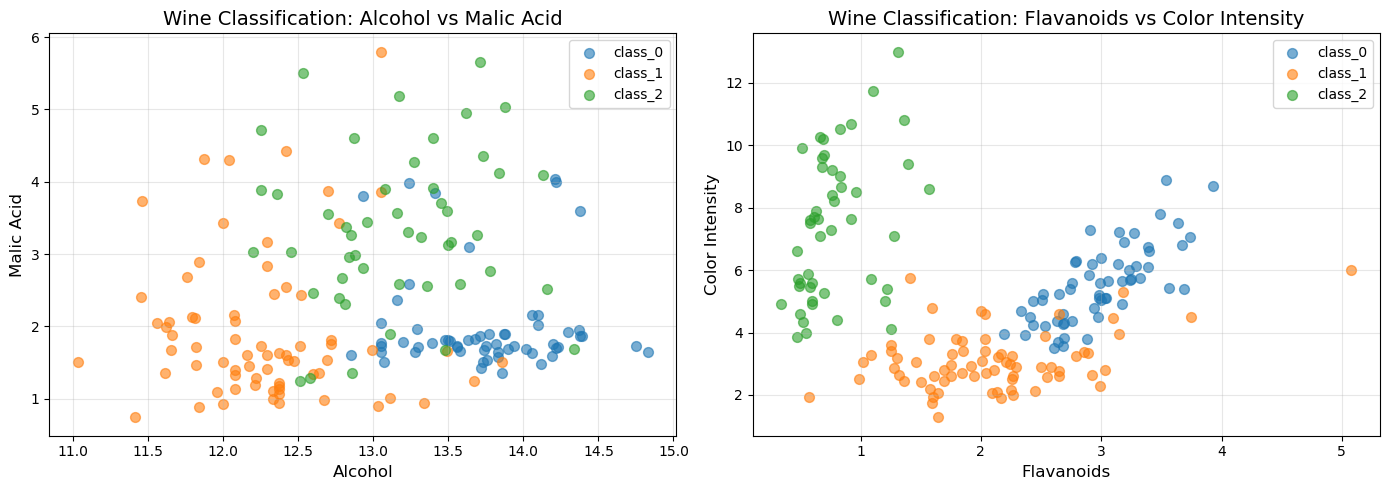

In [5]:
# Create scatter plots for two feature pairs
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Alcohol vs Malic Acid
for class_id in range(3):
    mask = y == class_id
    axes[0].scatter(X[mask, 0], X[mask, 1], 
                   label=wine_data.target_names[class_id], 
                   alpha=0.6, s=50)
axes[0].set_xlabel('Alcohol', fontsize=12)
axes[0].set_ylabel('Malic Acid', fontsize=12)
axes[0].set_title('Wine Classification: Alcohol vs Malic Acid', fontsize=14)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Flavanoids vs Color Intensity
for class_id in range(3):
    mask = y == class_id
    axes[1].scatter(X[mask, 6], X[mask, 9], 
                   label=wine_data.target_names[class_id], 
                   alpha=0.6, s=50)
axes[1].set_xlabel('Flavanoids', fontsize=12)
axes[1].set_ylabel('Color Intensity', fontsize=12)
axes[1].set_title('Wine Classification: Flavanoids vs Color Intensity', fontsize=14)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Part 2: Preprocess dataset

We'll split the data into 80% training and 20% testing.

In [6]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")
print(f"Number of features: {X_train.shape[1]}")

Training set size: 142 samples
Test set size: 36 samples
Number of features: 13


### Feature Normalization

**Why normalize?** k-NN uses distance metrics (like Euclidean distance) to find nearest neighbors. Features with larger scales will dominate the distance calculation. For example, if one feature ranges from 0-1000 and another from 0-1, the first feature will have much more influence on the distance.

**Standardization formula**: For each feature, compute $z = \frac{x - \mu}{\sigma}$ where $\mu$ is the mean and $\sigma$ is the standard deviation.

**TODO (b)**: Implement feature standardization. Complete the `standardize_features` function below.

In [ ]:
def standardize_features(X_train, X_test):
    """
    Standardize features by removing the mean and scaling to unit variance.
    
    Parameters:
    X_train: Training data array of shape (n_train_samples, n_features)
    X_test: Test data array of shape (n_test_samples, n_features)
    
    Returns:
    X_train_scaled: Standardized training data
    X_test_scaled: Standardized test data
    """
    # TODO: Compute mean and standard deviation from training data
    # IMPORTANT: Only use training data statistics to avoid data leakage
    mean = None  # Replace with your code
    std = None   # Replace with your code
    
    # TODO: Standardize both training and test data using training statistics
    X_train_scaled = None  # Replace with your code
    X_test_scaled = None   # Replace with your code
    
    return X_train_scaled, X_test_scaled

# Apply standardization
X_train_scaled, X_test_scaled = standardize_features(X_train, X_test)

print("Before standardization:")
print(f"  Training data mean: {X_train.mean(axis=0)[:3]}...")
print(f"  Training data std: {X_train.std(axis=0)[:3]}...")
print("\nAfter standardization:")
print(f"  Training data mean: {X_train_scaled.mean(axis=0)[:3]}...")
print(f"  Training data std: {X_train_scaled.std(axis=0)[:3]}...")

## Part 3: Implement k-NN Algorithm

Now we'll implement the k-NN algorithm from scratch. The algorithm works as follows:

1. **Calculate distances**: For a test point, compute the distance to all training points
2. **Find k nearest neighbors**: Select the k training points with smallest distances
3. **Vote for class**: The predicted class is the most common class among the k neighbors

We'll use Euclidean distance: $d(x, y) = \sqrt{\sum_{i=1}^{n} (x_i - y_i)^2}$

**TODO (c)**: Implement the Euclidean distance function.

In [ ]:
def euclidean_distance(x1, x2):
    """
    Calculate the Euclidean distance between two vectors.
    
    Parameters:
    x1, x2: numpy arrays of the same length
    
    Returns:
    distance: Euclidean distance (scalar)
    """
    # TODO: Implement Euclidean distance calculation
    # Hint: Use np.sqrt() and np.sum()
    distance = None  # Replace with your code
    
    return distance

# Test your function
test_point1 = np.array([1, 2, 3])
test_point2 = np.array([4, 6, 8])
print(f"Distance between {test_point1} and {test_point2}: {euclidean_distance(test_point1, test_point2):.4f}")
print(f"Expected: 7.0711")

**TODO (d)**: Implement the k-NN prediction function.

In [ ]:
def knn_predict(X_train, y_train, x_test, k):
    """
    Predict the class for a single test point using k-NN.
    
    Parameters:
    X_train: Training data array of shape (n_samples, n_features)
    y_train: Training labels array of shape (n_samples,)
    x_test: Single test point of shape (n_features,)
    k: Number of neighbors to consider
    
    Returns:
    prediction: Predicted class label
    """
    # TODO: Step 1 - Calculate distances from x_test to all training points
    distances = []  # Replace with your code
    # Hint: Loop through X_train and use euclidean_distance function
    
    # TODO: Step 2 - Get indices of k nearest neighbors
    # Hint: Use np.argsort() to sort distances and select first k indices
    k_indices = None  # Replace with your code
    
    # TODO: Step 3 - Get the labels of k nearest neighbors
    k_nearest_labels = None  # Replace with your code
    
    # TODO: Step 4 - Return the most common label
    # Hint: Use np.bincount() and np.argmax()
    prediction = None  # Replace with your code
    
    return prediction

# Test your function on a single test point
test_prediction = knn_predict(X_train_scaled, y_train, X_test_scaled[0], k=5)
print(f"Predicted class: {test_prediction}")
print(f"Actual class: {y_test[0]}")
print(f"Match: {test_prediction == y_test[0]}")

**TODO (e)**: Now implement a function to predict classes for multiple test points.

In [ ]:
def knn_predict_multiple(X_train, y_train, X_test, k):
    """
    Predict classes for multiple test points.
    
    Parameters:
    X_train: Training data
    y_train: Training labels
    X_test: Test data array of shape (n_test_samples, n_features)
    k: Number of neighbors
    
    Returns:
    predictions: Array of predicted labels
    """
    # TODO: Loop through all test points and predict each one
    predictions = []  # Replace with your code
    
    return np.array(predictions)

# Make predictions on test set
y_pred = knn_predict_multiple(X_train_scaled, y_train, X_test_scaled, k=5)
print(f"Predictions shape: {y_pred.shape}")
print(f"First 10 predictions: {y_pred[:10]}")
print(f"First 10 actual labels: {y_test[:10]}")

## Part 4: Evaluation and Interpretation

**TODO (f)**: Calculate the accuracy of your k-NN classifier.

In [ ]:
def calculate_accuracy(y_true, y_pred):
    """
    Calculate classification accuracy.
    
    Parameters:
    y_true: True labels
    y_pred: Predicted labels
    
    Returns:
    accuracy: Fraction of correct predictions
    """
    # TODO: Calculate accuracy
    accuracy = None  # Replace with your code
    
    return accuracy

# Calculate accuracy
accuracy = calculate_accuracy(y_test, y_pred)
print(f"\nTest Accuracy with k=5: {accuracy:.4f} ({accuracy*100:.2f}%)")

**TODO (g)**: Create a confusion matrix to see which classes are confused with each other.

In [ ]:
def confusion_matrix(y_true, y_pred, n_classes):
    """
    Create a confusion matrix.
    
    Parameters:
    y_true: True labels
    y_pred: Predicted labels
    n_classes: Number of classes
    
    Returns:
    cm: Confusion matrix of shape (n_classes, n_classes)
        cm[i,j] = number of samples with true class i predicted as class j
    """
    # TODO: Initialize confusion matrix
    cm = np.zeros((n_classes, n_classes), dtype=int)
    
    # TODO: Fill in the confusion matrix
    # Hint: Loop through predictions and increment cm[true_label, pred_label]
    
    return cm

# Create and display confusion matrix
cm = confusion_matrix(y_test, y_pred, n_classes=3)
print("\nConfusion Matrix:")
print("Rows: True class, Columns: Predicted class")
print(cm)

# Visualize confusion matrix
plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation='nearest', cmap='Blues')
plt.title('Confusion Matrix (k=5)', fontsize=14)
plt.colorbar()
tick_marks = np.arange(3)
plt.xticks(tick_marks, wine_data.target_names, rotation=45)
plt.yticks(tick_marks, wine_data.target_names)
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)

# Add text annotations
for i in range(3):
    for j in range(3):
        plt.text(j, i, str(cm[i, j]), ha='center', va='center', 
                color='white' if cm[i, j] > cm.max()/2 else 'black', fontsize=14)

plt.tight_layout()
plt.show()

### Effect of k on Performance

The choice of k is crucial in k-NN:
- **Small k** (e.g., k=1): More sensitive to noise, may overfit
- **Large k**: Smoother decision boundary, may underfit

Let's explore how k affects performance.

**TODO (h)**: Test different values of k and plot the results.

In [ ]:
# Test different values of k
k_values = range(1, 31)
train_accuracies = []
test_accuracies = []

# TODO: For each k value:
#   1. Make predictions on training and test sets
#   2. Calculate accuracies
#   3. Store accuracies in the lists

for k in k_values:
    # Your code here
    pass

# Plot results
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(k_values, train_accuracies, 'b-o', label='Training Accuracy', linewidth=2)
plt.plot(k_values, test_accuracies, 'r-s', label='Test Accuracy', linewidth=2)
plt.xlabel('k (Number of Neighbors)', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Accuracy vs k', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
gap = np.array(train_accuracies) - np.array(test_accuracies)
plt.plot(k_values, gap, 'g-^', linewidth=2)
plt.xlabel('k (Number of Neighbors)', fontsize=12)
plt.ylabel('Training - Test Accuracy', fontsize=12)
plt.title('Overfitting Gap vs k', fontsize=14)
plt.grid(True, alpha=0.3)
plt.axhline(y=0, color='black', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Find best k
best_k = k_values[np.argmax(test_accuracies)]
best_accuracy = max(test_accuracies)
print(f"\nBest k: {best_k}")
print(f"Best test accuracy: {best_accuracy:.4f} ({best_accuracy*100:.2f}%)")

### Visualizing Decision Boundaries

Let's visualize how k-NN makes decisions by plotting decision boundaries in 2D (using only 2 features for visualization).

In [ ]:
def plot_decision_boundary(X_train, y_train, X_test, y_test, k, feature_indices=[0, 1]):
    """
    Plot decision boundary for 2 features.
    
    Parameters:
    X_train, y_train: Training data and labels
    X_test, y_test: Test data and labels
    k: Number of neighbors
    feature_indices: Which two features to use for visualization
    """
    # Use only 2 features
    X_train_2d = X_train[:, feature_indices]
    X_test_2d = X_test[:, feature_indices]
    
    # Create mesh grid
    h = 0.02  # Step size
    x_min, x_max = X_train_2d[:, 0].min() - 1, X_train_2d[:, 0].max() + 1
    y_min, y_max = X_train_2d[:, 1].min() - 1, X_train_2d[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    
    # Predict class for each point in mesh
    mesh_points = np.c_[xx.ravel(), yy.ravel()]
    Z = knn_predict_multiple(X_train_2d, y_train, mesh_points, k)
    Z = Z.reshape(xx.shape)
    
    # Plot decision boundary
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.contourf(xx, yy, Z, alpha=0.4, cmap='viridis')
    scatter = plt.scatter(X_train_2d[:, 0], X_train_2d[:, 1], c=y_train, 
                         cmap='viridis', edgecolors='black', s=50, alpha=0.8)
    plt.xlabel(wine_data.feature_names[feature_indices[0]], fontsize=12)
    plt.ylabel(wine_data.feature_names[feature_indices[1]], fontsize=12)
    plt.title(f'Training Data Decision Boundary (k={k})', fontsize=14)
    plt.colorbar(scatter)
    
    plt.subplot(1, 2, 2)
    plt.contourf(xx, yy, Z, alpha=0.4, cmap='viridis')
    scatter = plt.scatter(X_test_2d[:, 0], X_test_2d[:, 1], c=y_test, 
                         cmap='viridis', edgecolors='black', s=50, alpha=0.8)
    plt.xlabel(wine_data.feature_names[feature_indices[0]], fontsize=12)
    plt.ylabel(wine_data.feature_names[feature_indices[1]], fontsize=12)
    plt.title(f'Test Data Decision Boundary (k={k})', fontsize=14)
    plt.colorbar(scatter)
    
    plt.tight_layout()
    plt.show()

# Visualize decision boundaries for different k values
print("Decision boundaries using features: Alcohol and Malic Acid\n")
for k in [1, 5, 15]:
    plot_decision_boundary(X_train_scaled, y_train, X_test_scaled, y_test, k, feature_indices=[0, 1])
    y_pred_2d = knn_predict_multiple(X_train_scaled[:, [0,1]], y_train, 
                                     X_test_scaled[:, [0,1]], k)
    acc = calculate_accuracy(y_test, y_pred_2d)
    print(f"Test accuracy with k={k} (2 features only): {acc:.4f}")
    print()

## Part 5: Discussion Questions

Answer the following questions based on your experiments:

**TODO (i)**: Answer these questions in the markdown cell below:

1. What happens to the training accuracy as k increases? Why?

2. What is the relationship between k and overfitting? Which k values show signs of overfitting?

3. Compare the decision boundaries for k=1, k=5, and k=15. How do they differ? Which one appears smoother?

4. Why is feature normalization important for k-NN? What would happen if we didn't normalize?

5. What are the advantages and disadvantages of k-NN compared to other classification algorithms?

6. When might k-NN perform poorly? Can you think of scenarios where distance-based classification wouldn't work well?

### Your Answers:

1. 

2. 

3. 

4. 

5. 

6. 

## Part 6: Weighted k-NN

**TODO (j)**: Implement weighted k-NN where closer neighbors have more influence on the prediction.

Instead of giving each neighbor equal vote, weight each neighbor's vote by the inverse of its distance:

$$w_i = \frac{1}{d_i}$$

where $d_i$ is the distance to neighbor $i$. Then predict the class with highest weighted vote.
Below, you will implement the new procedure and calculate it's performance on the test set.

In [7]:
def weighted_knn_predict(X_train, y_train, x_test, k):
    """
    Predict using weighted k-NN.
    
    Parameters:
    X_train: Training data
    y_train: Training labels
    x_test: Single test point
    k: Number of neighbors
    
    Returns:
    prediction: Predicted class
    """
    # TODO: Implement weighted k-NN
    # Hints:
    # 1. Calculate distances
    # 2. Find k nearest neighbors
    # 3. Calculate weights as 1/distance (handle distance=0 case)
    # 4. For each class, sum the weights of neighbors belonging to that class
    # 5. Return class with highest weighted sum
    
    pass

# Test weighted k-NN and compare with regular k-NN
# Your code here

## Summary

In this lab, you:
- Implemented the k-NN algorithm from scratch
- Learned about feature normalization and its importance
- Explored how the parameter k affects bias-variance tradeoff
- Visualized decision boundaries
- Evaluated classification performance using accuracy and confusion matrices

**Key Takeaways:**
- k-NN is a simple, intuitive algorithm that classifies based on proximity
- Choice of k is important: small k → overfitting, large k → underfitting
- Feature scaling is crucial for distance-based algorithms
- k-NN is a "lazy learner" - no training phase, but prediction can be slow for large datasets

Great work! You now understand one of the fundamental algorithms in machine learning.